In [9]:
# ==========================================
# TITANIC DATA PREPROCESSING - PART 1
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("data/train.csv")

print("Dataset Loaded Successfully!")

# ==========================================
# Display Dataset
# ==========================================

print("\nFirst 5 Rows")
print(df.head())

print("\nLast 5 Rows")
print(df.tail())

# ==========================================
# Dataset Shape
# ==========================================

print("\nShape of Dataset")
print(df.shape)

# ==========================================
# Column Names
# ==========================================

print("\nColumns")
print(df.columns)

# ==========================================
# Dataset Information
# ==========================================

print("\nInformation")
print(df.info())

# ==========================================
# Statistical Summary
# ==========================================

print("\nDescribe")
print(df.describe(include='all'))

# ==========================================
# Missing Values
# ==========================================

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================
# Fill Missing Values
# ==========================================

# Age -> Mean
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Embarked -> Mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin -> Unknown
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("\nMissing Values After Filling")
print(df.isnull().sum())

# ==========================================
# Duplicate Records
# ==========================================

print("\nDuplicate Rows")
print(df.duplicated().sum())

df = df.drop_duplicates()

print("\nDuplicate Rows After Removing")
print(df.duplicated().sum())

# ==========================================
# Minimum Values
# ==========================================

print("\nMinimum Values")
print(df.min(numeric_only=True))

# ==========================================
# Maximum Values
# ==========================================

print("\nMaximum Values")
print(df.max(numeric_only=True))

# ==========================================
# Mean
# ==========================================

print("\nMean")
print(df.mean(numeric_only=True))

# ==========================================
# Median
# ==========================================

print("\nMedian")
print(df.median(numeric_only=True))

# ==========================================
# Mode
# ==========================================

print("\nMode")
print(df.mode().iloc[0])

# ==========================================
# Standard Deviation
# ==========================================

print("\nStandard Deviation")
print(df.std(numeric_only=True))

# ==========================================
# Radian Conversion
# ==========================================

df["Age_Radian"] = np.radians(df["Age"])

print("\nAge and Age in Radians")
print(df[["Age", "Age_Radian"]].head())

# ==========================================
# Encode Categorical Columns
# ==========================================

df["Sex"] = df["Sex"].map({"male":0,"female":1})

df["Embarked"] = df["Embarked"].map({"S":0,"C":1,"Q":2})

print("\nEncoded Dataset")
print(df.head())

Dataset Loaded Successfully!

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0    

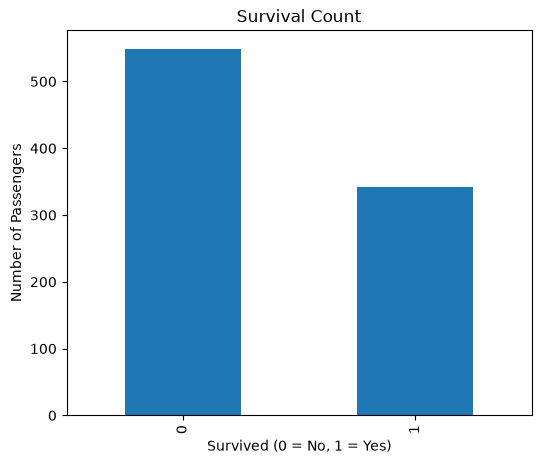

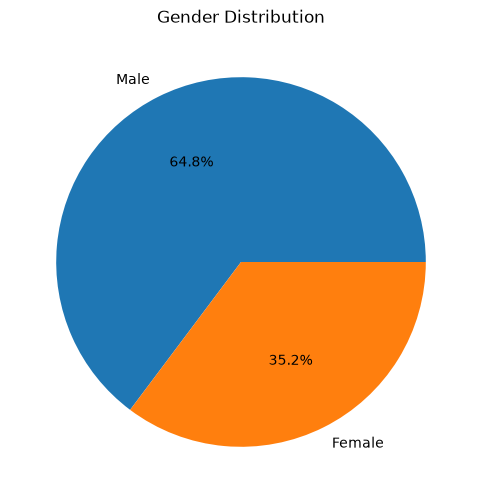

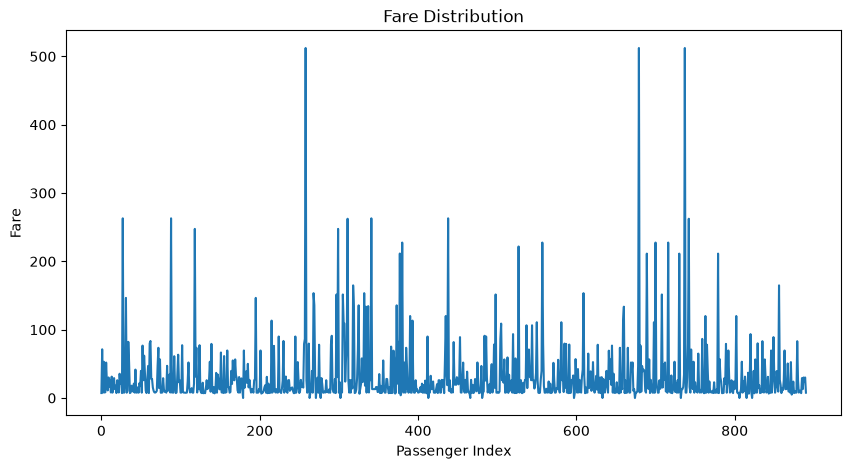

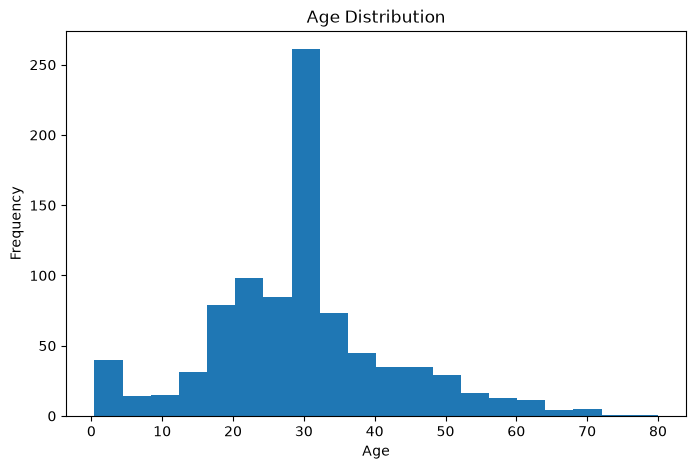

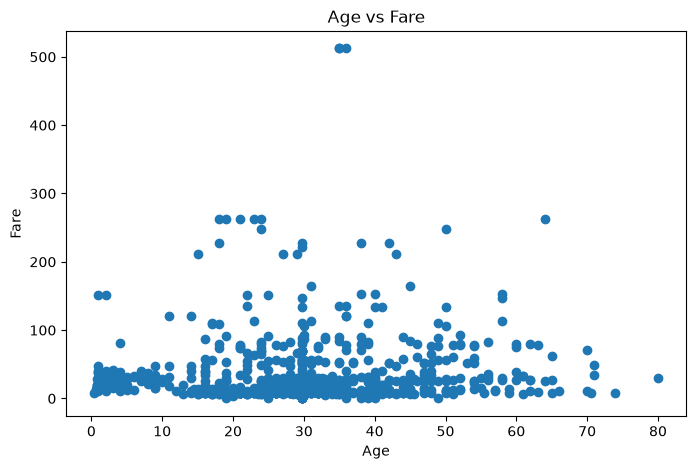

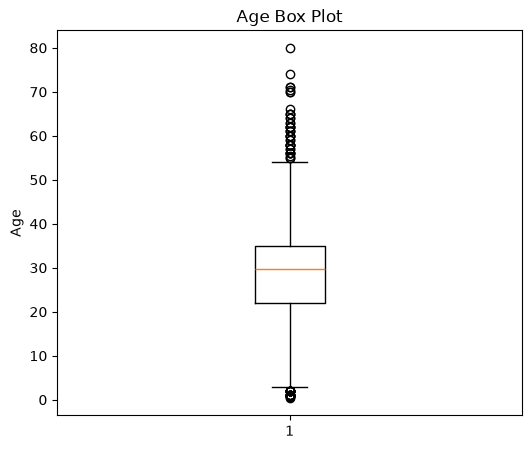

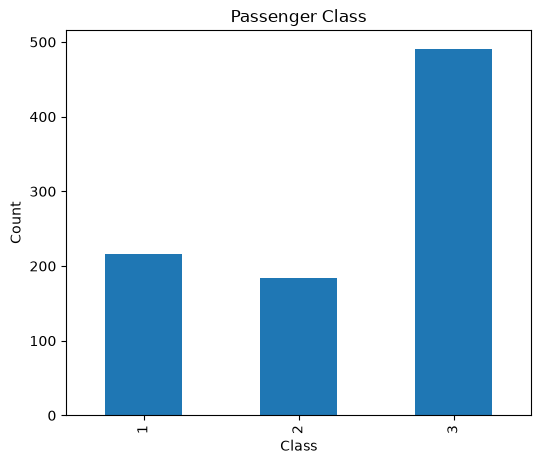

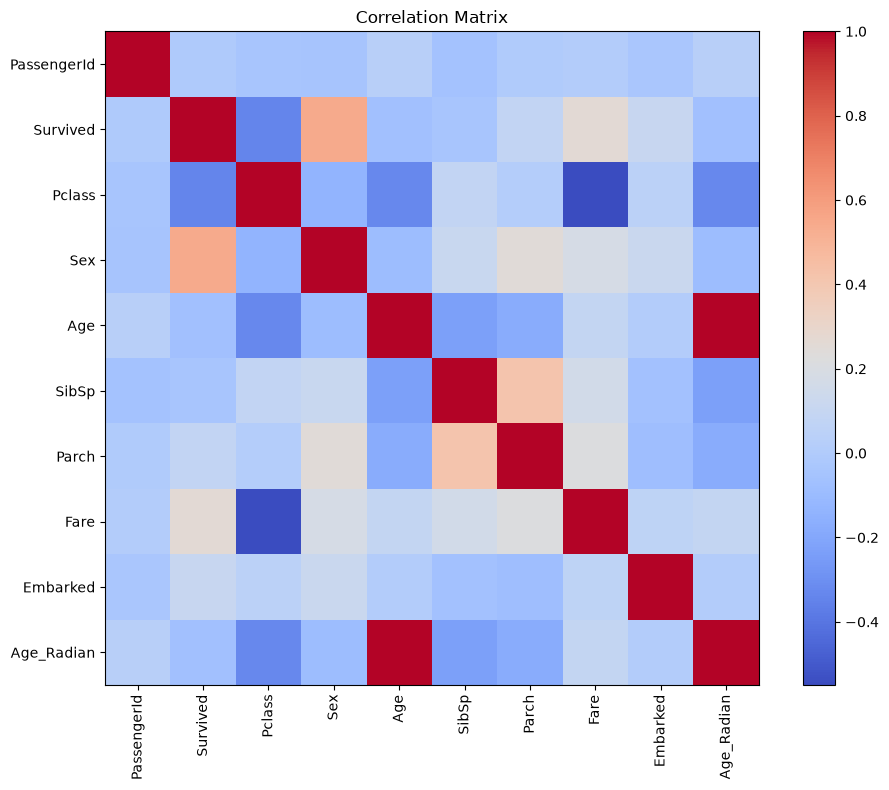

Cleaned dataset saved successfully!


In [10]:
# ==========================================
# TITANIC DATA VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

# ------------------------------------------
# 1. Bar Plot - Survival Count
# ------------------------------------------

plt.figure(figsize=(6,5))
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()


# ------------------------------------------
# 2. Pie Chart - Gender Distribution
# ------------------------------------------

plt.figure(figsize=(6,6))
gender = df["Sex"].replace({0:"Male",1:"Female"})
gender.value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()


# ------------------------------------------
# 3. Line Plot - Fare
# ------------------------------------------

plt.figure(figsize=(10,5))
plt.plot(df["Fare"])
plt.title("Fare Distribution")
plt.xlabel("Passenger Index")
plt.ylabel("Fare")
plt.show()


# ------------------------------------------
# 4. Histogram - Age
# ------------------------------------------

plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


# ------------------------------------------
# 5. Scatter Plot - Age vs Fare
# ------------------------------------------

plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Fare"])
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()


# ------------------------------------------
# 6. Box Plot - Age
# ------------------------------------------

plt.figure(figsize=(6,5))
plt.boxplot(df["Age"])
plt.title("Age Box Plot")
plt.ylabel("Age")
plt.show()


# ------------------------------------------
# 7. Bar Plot - Passenger Class
# ------------------------------------------

plt.figure(figsize=(6,5))
df["Pclass"].value_counts().sort_index().plot(kind="bar")
plt.title("Passenger Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


# ------------------------------------------
# 8. Correlation Matrix
# ------------------------------------------

plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=["number"]).corr()

plt.imshow(corr, cmap="coolwarm", interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()


# ------------------------------------------
# Save Cleaned Dataset
# ------------------------------------------

df.to_csv("output/cleaned_titanic.csv", index=False)

print("Cleaned dataset saved successfully!")